<a href="https://colab.research.google.com/github/Haikal7090/CarbonGuard/blob/main/CarbonGuard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CarbonGuard
[![Python 3.10](https://img.shields.io/badge/python-3.10-blue.svg)](https://www.python.org/downloads/release/python-3100/)
![Machine Learning](https://img.shields.io/badge/Machine_Learning-Robot-blue?logo=scikit-learn&logoColor=white)
![Isolation Forest](https://img.shields.io/badge/Isolation_Forest-Anomaly_Detection-red?logo=target&logoColor=white)
![Deep Autoencoder](https://img.shields.io/badge/Deep_Autoencoder-Neural_Network-orange?logo=pytorch&logoColor=white)


CarbonGuard : Hybrid Unsupervised ML for Real-Time Subsea CCUS Leak Detection
Location Focus: Tangguh UCC Project — West Papua, Indonesia.

CarbonGuard is an unsupervised machine learning (ML) framework designed to detect micro-leaks in subsea CO2 injection wells in real-time. Since actual field leakage data (anomalies) are extremely scarce, the system trains on normal operational profiles using a combination of multimodal sensor data: PDG (Permanent Downhole Gauge) for pressure data and DAS (Distributed Acoustic Sensing) for acoustic data.

# Key Features ( Updates):
1. Hybrid Dual-Model: Integrates Deep Autoencoders (AE) for feature extraction and denoising with Isolation Forest (iForest) for structural anomaly isolation within the latent space.
2. Multimodal Fusion & Cross-Validation: Alarms are triggered only if a temporal correlation of anomalies is detected across both pressure (PDG) and acoustic (DAS) modalities, significantly suppressing the False Alarm Rate (FAR).
3. Youden’s Index Optimization: Automatically determines optimal alarm thresholds to achieve the most effective balance between sensitivity and specificity.
4. TTD (Time-to-Detection) Tracking: Explicitly calculates the system's response time from the leak onset to the first valid detection.
5. Physical Realism: Incorporates simulations of water hammer effects, Joule-Thomson cooling, and broadband turbulent emissions, all calibrated to industrial sampling rates.


# Model Machine Learning

Import Libraries

In [51]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score
)
from scipy.signal import butter, filtfilt
import os
import warnings
warnings.filterwarnings('ignore')


Configuration

In [52]:
np.random.seed(42)

CFG = {
    # Data sintetis
    "n_seq_normal":  80,      # jumlah time-series normal
    "n_seq_anomaly": 40,      # jumlah time-series leak
    "seq_len":       512,     # panjang tiap sequence (sampel)
    "n_das_ch":      8,       # channel DAS
    "window_size":   64,      # ukuran sliding window → input AE
    "step":          32,      # stride 50% overlap

    # Tangguh reservoir (representatif)
    "P_baseline":    350.0,   # bar BHP
    "T_baseline":    80.0,    # °C BHT
    "P_noise_pct":   0.005,   # ±0.5% diurnal
    "fs_pdg":        1.0,     # Hz — PDG acquisition rate [v3-FIX-1]
    "fs_das":        1000.0,  # Hz — DAS (downsampled ke fs_pdg untuk fusion)

    # Autoencoder
    "hidden1":       128,
    "hidden2":       64,
    "bottleneck":    32,
    "lr":            0.001,
    "epochs":        300,
    "batch_size":    128,
    "patience":      25,
    "grad_clip":     1.0,

    # Isolation Forest
    "n_estimators":  100,
    "max_samples":   256,
    "contamination": 0.18,

    # Threshold (dikalibrasi dari percentile validasi normal)
    "recon_percentile": 97,
    "if_percentile":    80,

    # [v3-FIX-2] TTD: alarm persisten minimal N windows berturut-turut
    "ttd_persistence": 2,

    # Bobot skor gabungan: combined = sensor_weight × max(r_pdg, r_das) + if_weight × r_if
    # max(r_pdg, r_das) memilih modalitas yang lebih kuat agar tidak saling meredam.
    # Ubah nilai di sini untuk eksperimen tanpa menyentuh kode fungsi.
    "sensor_weight": 0.60,    # bobot komponen sensor (PDG dan DAS)
    "if_weight":     0.40,    # bobot Isolation Forest
}

N_FEAT = 1 + CFG["n_das_ch"]   # BHP + 8 DAS channel


Synthetic Data Generation

In [53]:
def bandpass_filter(sig, lo, hi, fs, order=4):
    """Butterworth band-pass, aman untuk berbagai panjang signal."""
    nyq = 0.5 * fs
    lc  = np.clip(lo / nyq, 1e-4, 0.999)
    hc  = np.clip(hi / nyq, 1e-4, 0.999)
    if lc >= hc:
        return sig
    b, a = butter(order, [lc, hc], btype='band')
    pl   = min(len(sig) - 1, 3 * (max(len(b), len(a)) - 1))
    return filtfilt(b, a, sig, padlen=pl)

def make_normal_sequence(seq_len):
    """
    BHP normal: diurnal + formation noise + slow drift.
    DAS normal: low-freq background + mechanical vibration harmonics.

    [v3-FIX-1] Harmonik pompa dimodelkan sebagai frekuensi rendah
    yang sesuai dengan fs_pdg=1 Hz:
      → f_pump ≈ 0.05 Hz  (siklus pompa ~20 detik)
      → f_mech ≈ 0.12 Hz  (getaran mechanical ~8 detik)
    Ini fisis karena PDG dan DAS sudah didownsample ke 1 Hz.
    """
    fs  = CFG["fs_pdg"]
    t   = np.arange(seq_len, dtype=float) / fs   # waktu dalam detik
    P0  = CFG["P_baseline"]

    # BHP
    diurnal = P0 * CFG["P_noise_pct"] * np.sin(2*np.pi * t / (seq_len/fs * 0.8))
    noise_P = np.random.normal(0, P0 * 0.002, seq_len)
    drift   = np.cumsum(np.random.randn(seq_len)) * (P0 * 0.0001)
    P       = P0 + diurnal + noise_P + drift

    out = np.zeros((seq_len, N_FEAT))
    out[:, 0] = P

    for c in range(CFG["n_das_ch"]):
        bg   = np.random.normal(0, 0.018, seq_len)

        # [v3-FIX-1] Pump harmonic di frekuensi yang fisis untuk fs=1 Hz
        f_pump = 0.05   # Hz: siklus 20 detik
        f_mech = 0.12   # Hz: getaran mekanikal
        pump   = (0.006 * np.sin(2*np.pi * f_pump * t + c * 0.4) +
                  0.003 * np.sin(2*np.pi * f_mech * t + c * 0.8))

        # Formation vibration (band-pass 0.02–0.4 Hz)
        raw_form = np.random.randn(seq_len)
        try:
            form_vib = bandpass_filter(raw_form, 0.02, 0.4, fs) * 0.01
        except Exception:
            form_vib = raw_form * 0.005

        out[:, 1 + c] = bg + pump + form_vib

    return out

def make_leak_sequence(seq_len, onset_frac=0.45):
    """
    Time-series leak dengan onset deterministik.
    PDG: pressure drop + water hammer (Joule-Thomson cooling).
    DAS: filtered broadband turbulent emission + spatial decay.
    """
    fs     = CFG["fs_pdg"]
    t      = np.arange(seq_len, dtype=float) / fs
    P0     = CFG["P_baseline"]
    onset  = int(seq_len * onset_frac)
    tau    = seq_len * 0.12
    idx    = np.arange(seq_len)

    # BHP normal components
    diurnal = P0 * CFG["P_noise_pct"] * np.sin(2*np.pi * t / (seq_len/fs * 0.8))
    noise_P = np.random.normal(0, P0 * 0.002, seq_len)
    drift   = np.cumsum(np.random.randn(seq_len)) * (P0 * 0.0001)

    # Leak transient
    dp       = -P0 * 0.003    # micro-leak: 0.3% pressure drop (detectable above noise)
    envelope = np.where(idx >= onset,
                        dp * (1 - np.exp(-(idx - onset) / tau)), 0.0)
    # Water hammer: osilasi teredam (Joukowsky effect)
    f_wh     = 0.08    # Hz — sesuai fs=1 Hz [v3-FIX-1]
    wh       = np.where(
        idx >= onset,
        0.15 * dp * np.sin(2*np.pi * f_wh * (idx - onset) / fs)
                  * np.exp(-(idx - onset) / 30),
        0.0
    )
    P = P0 + diurnal + noise_P + drift + envelope + wh

    out = np.zeros((seq_len, N_FEAT))
    out[:, 0] = P

    n_ch = CFG["n_das_ch"]
    for c in range(n_ch):
        bg     = np.random.normal(0, 0.018, seq_len)
        f_pump = 0.05; f_mech = 0.12
        pump   = (0.006 * np.sin(2*np.pi * f_pump * t + c * 0.4) +
                  0.003 * np.sin(2*np.pi * f_mech * t + c * 0.8))

        # [v3-FIX-1] DAS leak: broadband di 0.1–0.45 Hz (realistis di fs=1Hz)
        # Representasi turbulen dari CO₂ micro-leak yang didownsample
        sp_decay = np.exp(-0.35 * abs(c - n_ch // 2))
        raw_leak = np.random.randn(seq_len)
        try:
            filt_leak = bandpass_filter(raw_leak, 0.08, 0.45, fs) * 0.22 * sp_decay
        except Exception:
            filt_leak = raw_leak * 0.10 * sp_decay

        # Rise time bertahap setelah onset (fisis: kebocoran bertambah)
        rise = np.where(idx >= onset,
                        1 - np.exp(-(idx - onset) / 18.0), 0.0)

        # Low-freq thermal strain (CO₂ expansion cooling)
        strain_drift = np.where(
            idx >= onset,
            0.007 * sp_decay * np.cumsum(np.random.randn(seq_len)) / seq_len,
            0.0
        )
        out[:, 1 + c] = bg + pump + filt_leak * rise + strain_drift

    return out, onset

def generate_dataset():
    """
    Hasilkan windows dari N_SEQ time-series panjang.
    Label window = 1 jika onset leak jatuh di dalam window.
    Kembalikan juga data mentah per-sequence untuk TTD.
    """
    print("=" * 65)
    print("  CARBONGUARD   —  Synthetic Data Generation")
    print("=" * 65)

    win  = CFG["window_size"]
    step = CFG["step"]
    SL   = CFG["seq_len"]
    nn   = CFG["n_seq_normal"]
    na   = CFG["n_seq_anomaly"]
    onset_fracs = np.linspace(0.30, 0.70, na)

    X_win_list, y_win_list = [], []
    raw_sequences = []           # untuk TTD calculation
    seq_metadata  = []           # (is_leak, onset, seq_idx_start_in_X)

    # Normal sequences
    for i in range(nn):
        seq = make_normal_sequence(SL)
        seq_start = len(X_win_list)
        for s in range(0, SL - win, step):
            X_win_list.append(seq[s:s + win].ravel())
            y_win_list.append(0)
        raw_sequences.append((seq, 0, None))    # (data, is_leak, onset)
        seq_metadata.append(dict(
            is_leak=False, onset=None, seq_idx=i,
            win_start=seq_start, win_end=len(X_win_list)
        ))

    # Anomaly sequences
    for j in range(na):
        frac  = onset_fracs[j]
        seq, onset = make_leak_sequence(SL, onset_frac=frac)
        seq_start  = len(X_win_list)
        for s in range(0, SL - win, step):
            lbl = 1 if onset < (s + win) else 0
            X_win_list.append(seq[s:s + win].ravel())
            y_win_list.append(lbl)
        raw_sequences.append((seq, 1, onset))
        seq_metadata.append(dict(
            is_leak=True, onset=onset, seq_idx=nn + j,
            win_start=seq_start, win_end=len(X_win_list)
        ))

    X_all = np.array(X_win_list, dtype=np.float32)
    y_all = np.array(y_win_list, dtype=int)
    n0 = (y_all == 0).sum(); n1 = (y_all == 1).sum()

    print(f"\n  Normal   sequences: {nn}  → {n0} windows")
    print(f"  Leak     sequences: {na}  → {n1} windows (onset 30–70%)")
    print(f"  Total    windows  : {len(y_all)}")
    print(f"  Window dim        : {X_all.shape[1]} = {win}×{N_FEAT} fitur")

    # Sequence untuk visualisasi
    vis_norm = make_normal_sequence(SL)
    vis_anom, vis_onset = make_leak_sequence(SL, onset_frac=0.45)
    vis = dict(norm=vis_norm, anom=vis_anom, onset=vis_onset, SL=SL)

    return X_all, y_all, vis, raw_sequences, seq_metadata


Preprocessing

In [54]:
def preprocess(X_all, y_all):
    """Shuffle → stratified split 80/20 → scaler fit pada normal train."""
    perm  = np.random.permutation(len(y_all))
    X_all = X_all[perm]
    y_all = y_all[perm]

    n0  = np.where(y_all == 0)[0]
    n1  = np.where(y_all == 1)[0]
    t0  = int(0.8 * len(n0))
    t1  = int(0.8 * len(n1))

    tr_idx = np.hstack([n0[:t0], n1[:t1]])
    te_idx = np.hstack([n0[t0:], n1[t1:]])
    np.random.shuffle(tr_idx);  np.random.shuffle(te_idx)

    X_tr = X_all[tr_idx];  y_tr = y_all[tr_idx]
    X_te = X_all[te_idx];  y_te = y_all[te_idx]

    scaler = MinMaxScaler()
    scaler.fit(X_tr[y_tr == 0])          # fit HANYA normal training
    X_tr_s = scaler.transform(X_tr)
    X_te_s = scaler.transform(X_te)

    print(f"  Train: {len(X_tr_s)}"
          f"  (normal={(y_tr==0).sum()}, leak={(y_tr==1).sum()})")
    print(f"  Test : {len(X_te_s)}"
          f"  (normal={(y_te==0).sum()}, leak={(y_te==1).sum()})")
    return X_tr_s, y_tr, X_te_s, y_te, scaler


Deep AutoEncoder

In [55]:
def relu(x):    return np.maximum(0.0, x)
def relu_d(x):  return (x > 0).astype(np.float32)
def sigmoid(x): return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
def sig_d(x):   s = sigmoid(x); return s * (1 - s)

class AutoEncoder:
    """
    Single autoencoder: D→H1→H2→BN→H2→H1→D
    ReLU hidden, Sigmoid output, Adam + gradient clipping.
    """
    def __init__(self, d, h1, h2, bn):
        dims = [d, h1, h2, bn, h2, h1, d]
        self.dims = dims
        self.nl   = len(dims) - 1
        self.W = []; self.b = []
        self.mW = []; self.vW = []
        self.mb = []; self.vb = []
        self.t  = 0

        for i in range(self.nl):
            fi, fo = dims[i], dims[i+1]
            sc = np.sqrt(2.0/fi) if i < self.nl - 1 else np.sqrt(1.0/fi)
            self.W.append(np.random.randn(fi, fo).astype(np.float32) * sc)
            self.b.append(np.zeros((1, fo), dtype=np.float32))
            for lst in [self.mW, self.vW]: lst.append(np.zeros((fi,fo),dtype=np.float32))
            for lst in [self.mb, self.vb]: lst.append(np.zeros((1,fo),dtype=np.float32))

    def forward(self, X):
        self._A = [X]; self._Z = []
        A = X
        for i in range(self.nl):
            Z = A @ self.W[i] + self.b[i]
            A = relu(Z) if i < self.nl - 1 else sigmoid(Z)
            self._Z.append(Z); self._A.append(A)
        return A

    def backward(self, X, lr, clip):
        m = X.shape[0]
        b1, b2, eps = 0.9, 0.999, 1e-8
        self.t += 1
        dA = 2.0 * (self._A[-1] - X) / m

        for i in reversed(range(self.nl)):
            dZ = dA * (sig_d(self._Z[i]) if i == self.nl-1 else relu_d(self._Z[i]))
            dW = self._A[i].T @ dZ
            db = dZ.sum(axis=0, keepdims=True)

            nW = np.linalg.norm(dW)
            if nW > clip: dW *= clip / nW
            nb_ = np.linalg.norm(db)
            if nb_ > clip: db *= clip / nb_

            self.mW[i] = b1*self.mW[i] + (1-b1)*dW
            self.vW[i] = b2*self.vW[i] + (1-b2)*dW**2
            mWc = self.mW[i]/(1-b1**self.t); vWc = self.vW[i]/(1-b2**self.t)
            self.W[i] -= lr * mWc / (np.sqrt(vWc) + eps)

            self.mb[i] = b1*self.mb[i] + (1-b1)*db
            self.vb[i] = b2*self.vb[i] + (1-b2)*db**2
            mbc = self.mb[i]/(1-b1**self.t); vbc = self.vb[i]/(1-b2**self.t)
            self.b[i] -= lr * mbc / (np.sqrt(vbc) + eps)

            dA = dZ @ self.W[i].T

    def bottleneck(self, X):
        """
        Kembalikan representasi bottleneck (latent space) dari encoder.

        Arsitektur: [D, H1, H2, BN, H2, H1, D]  →  nl = 6 weight matrices
          W0: D  → H1   (encoder layer 0)
          W1: H1 → H2   (encoder layer 1)
          W2: H2 → BN   (encoder layer 2  ← bottleneck output di sini)
          W3: BN → H2   (decoder layer 0  ← TIDAK boleh dilewati)
          ...

        n_enc = nl // 2 = 3
        Loop range(n_enc) = [0, 1, 2]  → berhenti tepat setelah W2.
        Sebelumnya range(n_enc+1) melewati W3 (decoder) secara keliru.
        """
        A     = X
        n_enc = self.nl // 2   # jumlah layer encoder
        # Loop [0, 1, ..., n_enc-1] menerapkan:
        #   W0: D→H1,  W1: H1→H2,  W2: H2→BN
        # Setelah loop selesai, A = output bottleneck (dim=BN). ✓
        # CATATAN: n_enc=3 sehingga W[n_enc]=W[3]=BN→H2 adalah decoder.
        # Jangan lewati W[n_enc] — loop sudah berhenti di encoder terakhir.
        for i in range(n_enc):
            Z = A @ self.W[i] + self.b[i]
            A = relu(Z)
        return A   # bottleneck output dengan ReLU, konsisten dengan forward pass

    def rmse_per_sample(self, X):
        return np.sqrt(np.mean((X - self.forward(X))**2, axis=1))

    def train(self, X_tr, X_va, epochs, bs, lr, patience, clip, label=""):
        n = len(X_tr)
        best_val = np.inf; wait = 0
        bW = [w.copy() for w in self.W]; bb = [b_.copy() for b_ in self.b]
        tr_mse = []; va_mse = []; tr_rmse = []; va_rmse = []

        for ep in range(epochs):
            perm = np.random.permutation(n)
            for s in range(0, n, bs):
                batch = X_tr[perm[s:s+bs]]
                self.forward(batch); self.backward(batch, lr, clip)

            Xr_tr = self.forward(X_tr); Xr_va = self.forward(X_va)
            tl = float(np.mean((X_tr-Xr_tr)**2))
            vl = float(np.mean((X_va-Xr_va)**2))
            tr = float(np.sqrt(tl)); vr = float(np.sqrt(vl))
            tr_mse.append(tl); va_mse.append(vl)
            tr_rmse.append(tr); va_rmse.append(vr)

            if (ep+1) % 50 == 0:
                print(f"    [{label}] Epoch {ep+1:3d}/{epochs}"
                      f"  MSE val={vl:.6f}  RMSE val={vr:.5f}")

            if vl < best_val - 1e-7:
                best_val = vl; wait = 0
                bW = [w.copy() for w in self.W]
                bb = [b_.copy() for b_ in self.b]
            else:
                wait += 1
            if wait >= patience:
                print(f"    [{label}] Early stopping @ epoch {ep+1}")
                break

        self.W = bW; self.b = bb
        return tr_mse, va_mse, tr_rmse, va_rmse


def split_modalities(X_windows, win, n_das):
    """
    Pisahkan fitur PDG dan DAS dari flattened windows.
    X_windows: (n, win * N_FEAT)
    PDG: kolom BHP saja → (n, win)
    DAS: kolom 8 channel → (n, win * n_das)
    """
    nf   = 1 + n_das
    # Reshape: (n, win, nf) → pisah kolom
    Xr   = X_windows.reshape(-1, win, nf)
    X_pdg = Xr[:, :, 0]                            # (n, win) — BHP only
    X_das = Xr[:, :, 1:].reshape(-1, win * n_das)  # (n, win*8)
    return X_pdg.astype(np.float32), X_das.astype(np.float32)


Isolation Forest

In [56]:
def train_if(btl_normal):
    iforest = IsolationForest(
        n_estimators = CFG["n_estimators"],
        max_samples  = min(CFG["max_samples"], len(btl_normal)),
        contamination= CFG["contamination"],
        random_state = 42, n_jobs=-1
    )
    iforest.fit(btl_normal)
    return iforest


THRESHOLD KALIBRASI & COMBINED SCORE

In [57]:
def calibrate(ae_pdg, ae_das, iforest,
              X_pdg_val, X_das_val, btl_val,
              if_mn, if_mx):
    """
    Kalibrasi threshold RMSE dan IF menggunakan data validasi normal.

    [BUG-2 FIX] IF score dinormalisasi dengan if_mn, if_mx dari TRAINING,
    bukan dari val set sendiri. Ini memastikan skala skor konsisten di
    semua tahap (val, test, TTD scoring).
    """
    rmse_pdg_val = ae_pdg.rmse_per_sample(X_pdg_val)
    rmse_das_val = ae_das.rmse_per_sample(X_das_val)

    rt_pdg = np.percentile(rmse_pdg_val, CFG["recon_percentile"])
    rt_das = np.percentile(rmse_das_val, CFG["recon_percentile"])

    # [BUG-2 FIX] Gunakan if_mn, if_mx dari TRAINING (bukan val)
    if_raw_val  = iforest.score_samples(btl_val)
    if_norm_val = 1.0 - (if_raw_val - if_mn) / (if_mx - if_mn + 1e-9)
    it          = np.percentile(if_norm_val, CFG["if_percentile"])

    print(f"\n  [Threshold Terkalibrasi — Val Normal]")
    print(f"  RMSE PDG threshold  (p{CFG['recon_percentile']}): {rt_pdg:.6f}")
    print(f"  RMSE DAS threshold  (p{CFG['recon_percentile']}): {rt_das:.6f}")
    print(f"  IF score threshold  (p{CFG['if_percentile']}): {it:.5f}")
    return rt_pdg, rt_das, it

def combined_score_multimodal(rmse_pdg, rmse_das, if_norm,
                               rt_pdg, rt_das):
    """
    Skor gabungan tiga komponen untuk CarbonGuard alarm:
      - r_pdg   : RMSE PDG dinormalisasi oleh threshold (pressure transient)
      - r_das   : RMSE DAS dinormalisasi oleh threshold (acoustic emission)
      - if_norm : IF anomaly score, sudah dalam [0,1] — dipakai langsung

    [BUG-3 FIX] if_norm sudah berada di [0,1] dari normalisasi training.
    Membaginya lagi dengan threshold `it` (juga [0,1]) menyebabkan skor
    IF menjadi >5 dan tidak simetris dengan r_pdg/r_das.
    Solusi: gunakan if_norm secara langsung sebagai r_if.

    Combined = sensor_weight × max(r_pdg, r_das) + if_weight × if_norm
    Keduanya sudah dalam [0,1]; max() memilih modalitas yang lebih kuat.
    """
    r_pdg    = np.clip(rmse_pdg / (rt_pdg + 1e-9), 0, 2) / 2.0
    r_das    = np.clip(rmse_das / (rt_das + 1e-9), 0, 2) / 2.0
    r_sensor = np.maximum(r_pdg, r_das)   # modalitas terkuat
    w_s = CFG["sensor_weight"]
    w_i = CFG["if_weight"]
    return w_s * r_sensor + w_i * if_norm  # if_norm langsung, bukan /it


TIME-TO-DETECTION (TTD)

In [58]:
def compute_ttd(raw_sequences, ae_pdg, ae_das, iforest,
                scaler, rt_pdg, rt_das, if_mn, if_mx, alarm_thresh=0.5):
    # [BUG-3 FIX] `it` dihapus dari signature karena combined_score_multimodal
    # tidak lagi membutuhkan it (IF score dipakai langsung).
    """
    Hitung TTD per sequence leak secara eksplisit:
    Jalankan scoring secara kontinu pada raw time-series,
    cari window pertama di mana alarm terpicu dan persisten
    selama >= ttd_persistence windows berturut-turut.

    TTD = (window_alarm_pertama - onset) × step_seconds
    """
    win  = CFG["window_size"]
    step = CFG["step"]
    n_das= CFG["n_das_ch"]
    pers = CFG["ttd_persistence"]
    fs   = CFG["fs_pdg"]

    ttd_list = []
    for seq_data, is_leak, onset in raw_sequences:
        if not is_leak:
            continue

        # Sliding window scoring
        alarm_windows = []
        win_positions = list(range(0, len(seq_data) - win, step))
        if not win_positions:
            continue

        # Batch semua windows sekaligus
        X_batch = np.array([seq_data[s:s+win].ravel()
                             for s in win_positions], dtype=np.float32)
        X_batch_scaled = scaler.transform(X_batch)

        X_pdg_b, X_das_b = split_modalities(X_batch_scaled, win, n_das)
        rmse_pdg_b = ae_pdg.rmse_per_sample(X_pdg_b)
        rmse_das_b = ae_das.rmse_per_sample(X_das_b)

        btl_b    = np.hstack([ae_pdg.bottleneck(X_pdg_b),
                               ae_das.bottleneck(X_das_b)])
        if_raw_b = iforest.score_samples(btl_b)
        if_norm_b= 1.0 - (if_raw_b - if_mn) / (if_mx - if_mn + 1e-9)

        comb_b = combined_score_multimodal(
            rmse_pdg_b, rmse_das_b, if_norm_b, rt_pdg, rt_das)
        alarm_b = (comb_b > alarm_thresh).astype(int)

        # Cari alarm persisten pertama
        consec = 0; first_alarm_pos = None
        for wi, alm in enumerate(alarm_b):
            if alm:
                consec += 1
                if consec >= pers and first_alarm_pos is None:
                    first_alarm_pos = win_positions[wi - pers + 1]
            else:
                consec = 0

        if first_alarm_pos is not None and first_alarm_pos > onset:
            ttd_samples = first_alarm_pos - onset
            ttd_seconds = ttd_samples / fs
            ttd_list.append(ttd_seconds)

    if ttd_list:
        ttd_arr = np.array(ttd_list)
        print(f"\n  [v3-FIX-2] Time-to-Detection (TTD):")
        print(f"  Sequence leak terdeteksi  : {len(ttd_arr)}/{len([s for s in raw_sequences if s[1]])}")
        print(f"  TTD Mean ± Std : {ttd_arr.mean():.1f} ± {ttd_arr.std():.1f} detik")
        print(f"  TTD Min / Max  : {ttd_arr.min():.1f} / {ttd_arr.max():.1f} detik")
        print(f"  TTD < 300s (5 min): {(ttd_arr < 300).sum()}/{len(ttd_arr)}"
              f" ({100*(ttd_arr<300).mean():.0f}%)")
        return ttd_arr
    else:
        print("  [TTD] Tidak ada deteksi leak yang valid di raw sequences.")
        return np.array([])


THRESHOLD OPTIMAL — YOUDEN'S INDEX

In [59]:
def find_optimal_threshold(
        ae_pdg, ae_das, iforest,
        X_pdg_val_leak, X_das_val_leak,
        X_pdg_val_norm, X_das_val_norm,
        btl_val_leak, btl_val_norm,
        rt_pdg, rt_das, if_mn, if_mx):
    """
    Tidak memerlukan `it` karena combined_score_multimodal tidak lagi
    menggunakan it untuk normalisasi IF (IF score dipakai langsung).
    """
    """
    Cari threshold optimal untuk combined score menggunakan Youden's Index
    pada gabungan data validasi normal + leak (jika ada leak di val set).

    Youden's J = Sensitivity + Specificity - 1  = TPR - FPR
    Threshold optimal = argmax(J) sepanjang kurva ROC.

    Input : RMSE + IF scores pada val normal DAN val leak.
    Output: threshold_optimal (float), roc data untuk plot.
    """
    from sklearn.metrics import roc_curve, roc_auc_score

    # Hitung skor pada val normal
    rmse_pdg_n = ae_pdg.rmse_per_sample(X_pdg_val_norm)
    rmse_das_n = ae_das.rmse_per_sample(X_das_val_norm)
    if_raw_n   = iforest.score_samples(btl_val_norm)
    if_norm_n  = 1.0 - (if_raw_n - if_mn) / (if_mx - if_mn + 1e-9)
    comb_n     = combined_score_multimodal(
                     rmse_pdg_n, rmse_das_n, if_norm_n, rt_pdg, rt_das)

    # Hitung skor pada val leak
    rmse_pdg_a = ae_pdg.rmse_per_sample(X_pdg_val_leak)
    rmse_das_a = ae_das.rmse_per_sample(X_das_val_leak)
    if_raw_a   = iforest.score_samples(btl_val_leak)
    if_norm_a  = 1.0 - (if_raw_a - if_mn) / (if_mx - if_mn + 1e-9)
    comb_a     = combined_score_multimodal(
                     rmse_pdg_a, rmse_das_a, if_norm_a, rt_pdg, rt_das)

    scores_val = np.hstack([comb_n, comb_a])
    labels_val = np.hstack([np.zeros(len(comb_n)), np.ones(len(comb_a))])

    if len(np.unique(labels_val)) < 2 or len(comb_a) == 0:
        print("  [Youden] Tidak cukup data leak di val set → pakai threshold=0.5")
        return 0.5, None, None

    fpr, tpr, thresholds = roc_curve(labels_val, scores_val)
    youden_j = tpr - fpr
    best_idx  = np.argmax(youden_j)
    best_thr  = float(thresholds[best_idx])
    auc_val   = roc_auc_score(labels_val, scores_val)

    print("\n  [v4-FIX-4] Youden's Index — Threshold Optimal:")
    print(f"  Threshold optimal : {best_thr:.5f}"
          f"  (J={youden_j[best_idx]:.4f},"
          f"  TPR={tpr[best_idx]:.3f}, FPR={fpr[best_idx]:.3f})")
    print(f"  ROC-AUC (val)    : {auc_val:.4f}")
    return best_thr, fpr, tpr


Evaluasi

In [60]:
def evaluate(name, yt, yp, scores=None):
    cm_  = confusion_matrix(yt, yp, labels=[0, 1])
    tn, fp, fn, tp = cm_.ravel()
    acc  = (tp+tn) / (tp+tn+fp+fn+1e-9) * 100
    far  = fp / (fp+tn+1e-9) * 100
    dr   = tp / (tp+fn+1e-9) * 100
    prec = precision_score(yt, yp, zero_division=0) * 100
    f1_  = f1_score(yt, yp, zero_division=0) * 100
    auc  = roc_auc_score(yt, scores) if scores is not None else None

    print(f"\n  ── {name} ──")
    print(f"  Accuracy       : {acc:.2f}%")
    print(f"  Detection Rate : {dr:.2f}%")
    print(f"  Precision      : {prec:.2f}%")
    print(f"  F1-Score       : {f1_:.2f}%")
    print(f"  False Alarm    : {far:.2f}%")
    if auc is not None: print(f"  ROC-AUC        : {auc:.4f}")
    print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    return dict(name=name, acc=acc, dr=dr, prec=prec, f1=f1_,
                far=far, auc=auc or 0.0, cm=cm_)


Main

In [61]:
def main():
    win  = CFG["window_size"]
    n_das= CFG["n_das_ch"]

    # ── 1. Data ──────────────────────────────────────────────
    X_all, y_all, vis, raw_seqs, seq_meta = generate_dataset()

    # ── 2. Preprocess ────────────────────────────────────────
    print("\n[Stage 2] Preprocessing …")
    X_tr, y_tr, X_te, y_te, scaler = preprocess(X_all, y_all)

    # Pisah modalitas
    X_pdg_tr, X_das_tr = split_modalities(X_tr, win, n_das)
    X_pdg_te, X_das_te = split_modalities(X_te, win, n_das)

    # Data normal train untuk AE
    mask_tr_norm = (y_tr == 0)
    Xp_norm_tr   = X_pdg_tr[mask_tr_norm]
    Xd_norm_tr   = X_das_tr[mask_tr_norm]
    val_cut = int(0.2 * len(Xp_norm_tr))
    Xp_va = Xp_norm_tr[:val_cut];  Xp_tr_ae = Xp_norm_tr[val_cut:]
    Xd_va = Xd_norm_tr[:val_cut];  Xd_tr_ae = Xd_norm_tr[val_cut:]

    print(f"\n  AE train normal={len(Xp_tr_ae)}, val={len(Xp_va)}")
    print(f"  PDG input dim={Xp_tr_ae.shape[1]}, DAS input dim={Xd_tr_ae.shape[1]}")

    # ── 3. Dua Autoencoder (PDG & DAS) ───────────────────────
    def make_ae(d, tag):
        h1 = min(CFG["hidden1"], d-1)
        h2 = min(CFG["hidden2"], h1-1)
        bn = min(CFG["bottleneck"], h2-1)
        print(f"\n[Stage 3-{tag}] AE {d}→{h1}→{h2}→{bn}→{h2}→{h1}→{d}")
        ae_ = AutoEncoder(d, h1, h2, bn)
        return ae_, h1, h2, bn

    ae_pdg, *_ = make_ae(Xp_tr_ae.shape[1], "PDG")
    tr_mse_p, va_mse_p, tr_rmse_p, va_rmse_p = ae_pdg.train(
        Xp_tr_ae, Xp_va, CFG["epochs"], CFG["batch_size"],
        CFG["lr"], CFG["patience"], CFG["grad_clip"], label="PDG"
    )

    ae_das, *_ = make_ae(Xd_tr_ae.shape[1], "DAS")
    tr_mse_d, va_mse_d, tr_rmse_d, va_rmse_d = ae_das.train(
        Xd_tr_ae, Xd_va, CFG["epochs"], CFG["batch_size"],
        CFG["lr"], CFG["patience"], CFG["grad_clip"], label="DAS"
    )

    # RMSE test
    rmse_pdg_te = ae_pdg.rmse_per_sample(X_pdg_te)
    rmse_das_te = ae_das.rmse_per_sample(X_das_te)

    rp_n = rmse_pdg_te[y_te==0]; rp_a = rmse_pdg_te[y_te==1]
    rd_n = rmse_das_te[y_te==0]; rd_a = rmse_das_te[y_te==1]
    print(f"\n  RMSE PDG — Normal: {rp_n.mean():.5f}±{rp_n.std():.5f}"
          f"  Leak: {rp_a.mean():.5f}±{rp_a.std():.5f}"
          f"  Ratio: {rp_a.mean()/rp_n.mean():.2f}×")
    print(f"  RMSE DAS — Normal: {rd_n.mean():.5f}±{rd_n.std():.5f}"
          f"  Leak: {rd_a.mean():.5f}±{rd_a.std():.5f}"
          f"  Ratio: {rd_a.mean()/rd_n.mean():.2f}×")

    # ── 4. Bottleneck → IF ───────────────────────────────────
    print("\n[Stage 4] Isolation Forest …")
    btl_norm_tr = np.hstack([ae_pdg.bottleneck(Xp_norm_tr[val_cut:]),
                              ae_das.bottleneck(Xd_norm_tr[val_cut:])])
    btl_norm_va = np.hstack([ae_pdg.bottleneck(Xp_va),
                              ae_das.bottleneck(Xd_va)])
    btl_te      = np.hstack([ae_pdg.bottleneck(X_pdg_te),
                              ae_das.bottleneck(X_das_te)]) # Changed Xd_te to X_das_te

    iforest = train_if(btl_norm_tr)

    # Normalisasi IF dari training
    raw_tr  = iforest.score_samples(btl_norm_tr)
    if_mn   = raw_tr.min(); if_mx = raw_tr.max()
    raw_te  = iforest.score_samples(btl_te)
    if_norm = 1.0 - (raw_te - if_mn) / (if_mx - if_mn + 1e-9)

    # ── 5. Kalibrasi threshold dari percentile val normal ────────
    rt_pdg, rt_das, it = calibrate(
        ae_pdg, ae_das, iforest, Xp_va, Xd_va, btl_norm_va,
        if_mn, if_mx)

    # ── 5b. [v4-FIX-4] Siapkan val leak untuk Youden's Index ─
    # Ambil sebagian data leak dari training set sebagai val leak
    mask_tr_leak  = (y_tr == 1)
    Xp_val_leak   = X_pdg_tr[mask_tr_leak][:50]   # max 50 samples
    Xd_val_leak   = X_das_tr[mask_tr_leak][:50]
    btl_val_leak  = np.hstack([ae_pdg.bottleneck(Xp_val_leak),
                                ae_das.bottleneck(Xd_val_leak)])

    # Cari threshold optimal via Youden's Index
    opt_thresh, fpr_youden, tpr_youden = find_optimal_threshold(
        ae_pdg, ae_das, iforest,
        Xp_val_leak, Xd_val_leak,
        Xp_va, Xd_va,
        btl_val_leak, btl_norm_va,
        rt_pdg, rt_das, if_mn, if_mx
    )

    # ── 6. Prediksi & Skor Gabungan ──────────────────────────
    comb  = combined_score_multimodal(
        rmse_pdg_te, rmse_das_te, if_norm, rt_pdg, rt_das)

    yp_pdg = (rmse_pdg_te > rt_pdg   ).astype(int)
    yp_das = (rmse_das_te > rt_das   ).astype(int)
    yp_if  = (if_norm     > it       ).astype(int)
    yp_cg  = (comb        > opt_thresh).astype(int)   # threshold dari Youden

    # ── 7. Evaluasi ──────────────────────────────────────────
    print("\n" + "=" * 65)
    print("  HASIL EVALUASI")
    print("=" * 65)
    r_pdg = evaluate("AE PDG Only (RMSE)",       y_te, yp_pdg, rmse_pdg_te)
    r_das = evaluate("AE DAS Only (RMSE)",        y_te, yp_das, rmse_das_te)
    r_if  = evaluate("Isolation Forest",           y_te, yp_if,  if_norm)
    r_cg  = evaluate("CarbonGuard (PDG+DAS+IF)",  y_te, yp_cg,  comb)

    print(f"\n  RMSE Summary:")
    print(f"  PDG sep. ratio : {rp_a.mean()/rp_n.mean():.2f}×"
          f"  (thresh={rt_pdg:.5f})")
    print(f"  DAS sep. ratio : {rd_a.mean()/rd_n.mean():.2f}×"
          f"  (thresh={rt_das:.5f})")

    # ── 8. TTD ───────────────────────────────────────────────
    print("\n[Stage 8] Time-to-Detection …")
    ttd_arr = compute_ttd(raw_seqs, ae_pdg, ae_das, iforest,
                          scaler, rt_pdg, rt_das, if_mn, if_mx,
                          alarm_thresh=opt_thresh)

    # ── 9. Visualisasi — setiap plot disimpan sebagai PNG terpisah ────
    print("\n[Stage 9] Visualisasi …")
    out_dir = 'outputs'
    os.makedirs(out_dir, exist_ok=True)

    DARK='#0d1117'; PANEL='#161b22'
    BLUE='#58a6ff'; GREEN='#3fb950'; RED='#f85149'
    ORANGE='#d29922'; TEXT='#c9d1d9'; MUTED='#8b949e'; TEAL='#39d353'
    PURPLE='#bc8cff'

    def sax(ax, title=''):
        ax.set_facecolor(PANEL)
        for sp in ax.spines.values(): sp.set_color('#30363d')
        ax.tick_params(colors=TEXT, labelsize=9)
        ax.xaxis.label.set_color(TEXT); ax.yaxis.label.set_color(TEXT)
        if title:
            ax.set_title(title, color=TEXT, fontsize=10,
                         fontweight='bold', pad=8)

    def savefig(fname, fig):
        """Simpan figure, tutup, dan print ke terminal."""
        path = os.path.join(out_dir, fname)
        fig.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK)
        plt.close(fig)
        print(f"  ✓ {fname}")
        print(f"    → {path}")

    SL    = vis["SL"]
    t_vis = np.arange(SL)
    onset = vis["onset"]

    # ── Plot 1: PDG Signal (BHP) ──────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_facecolor(DARK)
    ax.plot(t_vis, vis["norm"][:, 0], color=BLUE, lw=0.9, label='Normal BHP')
    ax.plot(t_vis, vis["anom"][:, 0], color=RED,  lw=0.9, label='Leak BHP')
    ax.axvline(onset, color=ORANGE, lw=1.3, ls='--', label=f'Onset @ sample {onset}')
    ax.set_xlabel('Sample (@ 1 Hz)', fontsize=9)
    ax.set_ylabel('BHP (bar)', fontsize=9)
    ax.legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED, labelcolor=TEXT)
    sax(ax, 'PDG — Bottomhole Pressure (BHP): Normal vs Leak')
    savefig('01_pdg_signal.png', fig)

    # ── Plot 2: DAS Channel 1 Signal ─────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_facecolor(DARK)
    ax.plot(t_vis, vis["norm"][:, 1], color=BLUE, lw=0.9, label='Normal DAS-CH1')
    ax.plot(t_vis, vis["anom"][:, 1], color=RED,  lw=0.9, label='Leak DAS-CH1')
    ax.axvline(onset, color=ORANGE, lw=1.3, ls='--', label=f'Onset @ sample {onset}')
    ax.set_xlabel('Sample (@ 1 Hz)', fontsize=9)
    ax.set_ylabel('Amplitude', fontsize=9)
    ax.legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED, labelcolor=TEXT)
    sax(ax, 'DAS — Channel 1: Normal vs Leak (Broadband 0.08–0.45 Hz)')
    savefig('02_das_signal_ch1.png', fig)

    # ── Plot 3: DAS Spatial Profile ───────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    fig.patch.set_facecolor(DARK)
    snap_norm = np.abs(vis["norm"][onset+50, 1:])
    snap_anom = np.abs(vis["anom"][onset+50, 1:])
    ch_idx = np.arange(1, n_das+1)
    ax.bar(ch_idx-0.2, snap_norm, 0.35, color=BLUE, alpha=0.8, label='Normal')
    ax.bar(ch_idx+0.2, snap_anom, 0.35, color=RED,  alpha=0.8, label='Leak')
    ax.set_xlabel('DAS Channel', fontsize=9)
    ax.set_ylabel('|Amplitude| — Spatial Decay', fontsize=9)
    ax.legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED, labelcolor=TEXT)
    sax(ax, 'DAS — Spatial Profile: Amplitudo per Channel (Normal vs Leak)')
    savefig('03_das_spatial_profile.png', fig)

    # ── Plot 4: AE PDG Training Curve ─────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.patch.set_facecolor(DARK)
    axes[0].plot(tr_mse_p,  color=BLUE,   lw=1.5, label='Train MSE')
    axes[0].plot(va_mse_p,  color=GREEN,  lw=1.5, ls='--', label='Val MSE')
    axes[0].set_xlabel('Epoch', fontsize=9); axes[0].set_ylabel('MSE', fontsize=9)
    axes[0].legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED, labelcolor=TEXT)
    sax(axes[0], 'AE PDG — MSE Training Curve')
    axes[1].plot(tr_rmse_p, color=ORANGE, lw=1.5, label='Train RMSE')
    axes[1].plot(va_rmse_p, color=TEAL,   lw=1.5, ls='--', label='Val RMSE')
    axes[1].set_xlabel('Epoch', fontsize=9); axes[1].set_ylabel('RMSE', fontsize=9)
    axes[1].legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED, labelcolor=TEXT)
    sax(axes[1], 'AE PDG — RMSE Training Curve')
    fig.tight_layout()
    savefig('04_ae_pdg_training.png', fig)

    # ── Plot 5: AE DAS Training Curve ─────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    fig.patch.set_facecolor(DARK)
    ax.plot(tr_rmse_d, color=PURPLE, lw=1.5, label='Train RMSE DAS')
    ax.plot(va_rmse_d, color=RED,    lw=1.5, ls='--', label='Val RMSE DAS')
    ax.set_xlabel('Epoch', fontsize=9); ax.set_ylabel('RMSE', fontsize=9)
    ax.legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED, labelcolor=TEXT)
    sax(ax, 'AE DAS — RMSE Training Curve')
    savefig('05_ae_das_training.png', fig)

    # ── Plot 6: RMSE Distribution PDG ─────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    fig.patch.set_facecolor(DARK)
    bins_r = np.linspace(0, rmse_pdg_te.max()*1.1, 70)
    ax.hist(rp_n, bins=bins_r, color=BLUE, alpha=0.75, label='Normal', density=True)
    ax.hist(rp_a, bins=bins_r, color=RED,  alpha=0.75, label='Leak',   density=True)
    ax.axvline(rt_pdg, color=ORANGE, lw=1.8, ls='--', label=f'Threshold={rt_pdg:.4f}')
    ax.set_xlabel('RMSE PDG', fontsize=9); ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED, labelcolor=TEXT)
    sax(ax, 'AE PDG — RMSE Distribution: Normal vs Leak')
    savefig('06_rmse_pdg_distribution.png', fig)

    # ── Plot 7: RMSE Distribution DAS ─────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    fig.patch.set_facecolor(DARK)
    bins_d = np.linspace(0, rmse_das_te.max()*1.1, 70)
    ax.hist(rd_n, bins=bins_d, color=BLUE,   alpha=0.75, label='Normal', density=True)
    ax.hist(rd_a, bins=bins_d, color=RED,    alpha=0.75, label='Leak',   density=True)
    ax.axvline(rt_das, color=PURPLE, lw=1.8, ls='--', label=f'Threshold={rt_das:.4f}')
    ax.set_xlabel('RMSE DAS', fontsize=9); ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED, labelcolor=TEXT)
    sax(ax, 'AE DAS — RMSE Distribution: Normal vs Leak')
    savefig('07_rmse_das_distribution.png', fig)

    # ── Plot 8: Isolation Forest Score ────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    fig.patch.set_facecolor(DARK)
    ax.hist(if_norm[y_te==0], bins=70, color=BLUE, alpha=0.75, label='Normal', density=True)
    ax.hist(if_norm[y_te==1], bins=70, color=RED,  alpha=0.75, label='Leak',   density=True)
    ax.axvline(it, color=ORANGE, lw=1.8, ls='--', label=f'Threshold={it:.3f}')
    ax.set_xlabel('IF Anomaly Score', fontsize=9); ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED, labelcolor=TEXT)
    sax(ax, 'Isolation Forest — Score Distribution: Normal vs Leak')
    savefig('08_isolation_forest_score.png', fig)

    # ── Plot 9: Combined Score Distribution ───────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    fig.patch.set_facecolor(DARK)
    ax.hist(comb[y_te==0], bins=70, color=BLUE, alpha=0.75, label='Normal', density=True)
    ax.hist(comb[y_te==1], bins=70, color=RED,  alpha=0.75, label='Leak',   density=True)
    ax.axvline(opt_thresh, color=ORANGE, lw=1.8, ls='--',
               label=f'Alarm={opt_thresh:.3f} (Youden)')
    ax.set_xlabel('Combined Score (PDG+DAS+IF)', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED, labelcolor=TEXT)
    sax(ax, 'CarbonGuard — Combined Score Distribution')
    savefig('09_combined_score_distribution.png', fig)

    # ── Plot 10: ROC Curve ────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 6))
    fig.patch.set_facecolor(DARK)
    for nm_, sc_, col_ in [
        ("AE PDG",           rmse_pdg_te, BLUE),
        ("AE DAS",           rmse_das_te, PURPLE),
        ("Isolation Forest", if_norm,     GREEN),
        ("CarbonGuard",      comb,        ORANGE),
    ]:
        fpr_, tpr_, _ = roc_curve(y_te, sc_)
        auc_          = roc_auc_score(y_te, sc_)
        ax.plot(fpr_, tpr_, color=col_, lw=1.8, label=f'{nm_}  AUC={auc_:.3f}')
    ax.plot([0,1],[0,1], color=MUTED, lw=0.8, ls='--')
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)
    ax.legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED, labelcolor=TEXT)
    sax(ax, 'ROC Curve — Perbandingan AE PDG / AE DAS / IF / CarbonGuard')
    savefig('10_roc_curve.png', fig)

    # ── Plot 11: Confusion Matrix CarbonGuard ─────────────────
    fig, ax = plt.subplots(figsize=(5, 4))
    fig.patch.set_facecolor(DARK)
    cm_cg = r_cg["cm"]
    ax.imshow(cm_cg, cmap='Blues', aspect='auto')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Normal','Leak'], color=TEXT, fontsize=11)
    ax.set_yticklabels(['Normal','Leak'], color=TEXT, fontsize=11)
    ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('Actual', fontsize=9)
    thr_cm = cm_cg.max() * 0.6
    for ii in range(2):
        for jj in range(2):
            ax.text(jj, ii, str(cm_cg[ii,jj]), ha='center', va='center',
                    color='white' if cm_cg[ii,jj]>thr_cm else TEXT,
                    fontsize=20, fontweight='bold')
    sax(ax, 'Confusion Matrix — CarbonGuard ')
    savefig('11_confusion_matrix.png', fig)

    # ── Plot 12: TTD Distribution ─────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    fig.patch.set_facecolor(DARK)
    if len(ttd_arr) > 1:
        ax.hist(ttd_arr, bins=min(15, len(ttd_arr)),
                color=TEAL, alpha=0.85, edgecolor=DARK)
        ax.axvline(300, color=RED, lw=1.5, ls='--', label='Target < 5 menit (300s)')
        ax.axvline(ttd_arr.mean(), color=ORANGE, lw=1.5,
                   label=f'Mean = {ttd_arr.mean():.0f}s')
        ax.set_xlabel('TTD (detik)', fontsize=9)
        ax.set_ylabel('Frekuensi', fontsize=9)
        ax.legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED, labelcolor=TEXT)
    else:
        ax.text(0.5, 0.5, 'TTD: Data tidak cukup\n(< 2 sequence terdeteksi)',
                ha='center', va='center', color=TEXT, fontsize=12,
                transform=ax.transAxes)
    sax(ax, 'Time-to-Detection (TTD) Distribution')
    savefig('12_ttd_distribution.png', fig)

    # ── Plot 13: 2D Scatter RMSE PDG vs DAS ───────────────────
    fig, ax = plt.subplots(figsize=(7, 6))
    fig.patch.set_facecolor(DARK)
    ax.scatter(rmse_pdg_te[y_te==0], rmse_das_te[y_te==0],
               s=12, color=BLUE, alpha=0.35, label='Normal')
    ax.scatter(rmse_pdg_te[y_te==1], rmse_das_te[y_te==1],
               s=40, color=RED,  alpha=0.85, label='Leak', zorder=5)
    ax.axvline(rt_pdg, color=ORANGE, lw=1.2, ls='--', alpha=0.8,
               label=f'PDG thresh={rt_pdg:.4f}')
    ax.axhline(rt_das, color=PURPLE, lw=1.2, ls='--', alpha=0.8,
               label=f'DAS thresh={rt_das:.4f}')
    ax.set_xlabel('RMSE PDG', fontsize=9); ax.set_ylabel('RMSE DAS', fontsize=9)
    ax.legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED, labelcolor=TEXT)
    sax(ax, '2D Scatter: RMSE PDG vs RMSE DAS — Separasi Normal/Leak')
    savefig('13_scatter_rmse_pdg_vs_das.png', fig)

    # ── Plot 14: CarbonGuard Score Timeline ───────────────────
    fig, ax = plt.subplots(figsize=(12, 4))
    fig.patch.set_facecolor(DARK)
    tidx = np.arange(len(y_te))
    ax.scatter(tidx[y_te==0], comb[y_te==0], s=8,  color=BLUE,
               alpha=0.35, label='Normal')
    ax.scatter(tidx[y_te==1], comb[y_te==1], s=20, color=RED,
               alpha=0.9,  label='Leak', zorder=5)
    ax.axhline(opt_thresh, color=ORANGE, lw=1.2, ls='--',
               label=f'Alarm = {opt_thresh:.3f} (Youden)')
    ax.set_xlabel('Window Index (Test Set)', fontsize=9)
    ax.set_ylabel('Combined Score', fontsize=9)
    ax.legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED, labelcolor=TEXT)
    sax(ax, 'CarbonGuard — Score Timeline (Test Set)')
    savefig('14_score_timeline.png', fig)

    # ── Plot 15: Metric Comparison Bar Chart ──────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor(DARK)
    models_  = ["AE PDG", "AE DAS", "Isolation Forest", "CarbonGuard"]
    results_ = [r_pdg, r_das, r_if, r_cg]
    keys_    = ["acc", "dr", "prec", "f1", "far"]
    cols_    = [BLUE, GREEN, RED, TEAL, ORANGE]
    lbls_    = ["Accuracy (%)", "Detection Rate (%)",
                "Precision (%)", "F1-Score (%)", "False Alarm (%)"]
    x_ = np.arange(len(models_)); w_ = 0.14
    for ki, (k, col, lbl) in enumerate(zip(keys_, cols_, lbls_)):
        vals = [r[k] for r in results_]
        ax.bar(x_ + (ki-2)*w_, vals, w_, color=col, label=lbl, alpha=0.85)
    ax.set_xticks(x_)
    ax.set_xticklabels(models_, color=TEXT, fontsize=11)
    ax.set_ylabel('Score (%)', fontsize=9); ax.set_ylim(0, 118)
    ax.axhline(95, color=MUTED, lw=0.8, ls=':', alpha=0.5)
    ax.text(3.45, 96.5, 'Target ≥ 95%', color=MUTED, fontsize=8)
    ax.legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED,
              labelcolor=TEXT, loc='upper left', ncol=5)
    sax(ax, 'Perbandingan Metrik: AE PDG | AE DAS | IF | CarbonGuard ')
    savefig('15_metric_comparison.png', fig)

    print(f"\n  Total: 15 file PNG tersimpan di → {out_dir}")

    # ── 10. CSV ──────────────────────────────────────────────
    # 10a. raw_synthetic_data.csv — time-series mentah per sequence ────
    print("\n[Stage 10] Ekspor CSV …")
    raw_frames = []
    for seq_data, is_leak, onset_val in raw_seqs:
        df_tmp = pd.DataFrame(
            seq_data,
            columns=['BHP'] + [f'DAS_CH{j+1}' for j in range(CFG['n_das_ch'])]
        )
        df_tmp['sequence_id']       = len(raw_frames)
        df_tmp['is_leak_sequence']  = int(is_leak)
        df_tmp['leak_onset_sample'] = int(onset_val) if onset_val is not None else -1
        df_tmp['sample_index']      = df_tmp.index
        raw_frames.append(df_tmp)

    raw_df = pd.concat(raw_frames, ignore_index=True)
    raw_path = os.path.join(out_dir, 'raw_synthetic_data.csv')
    raw_df.to_csv(raw_path, index=False)
    print(f"  ✓ raw_synthetic_data.csv  ({len(raw_df):,} baris)")
    print(f"    → {raw_path}")

    # 10b. predictions (test windows) ─────────────────────────
    pd.DataFrame({
        'true_label'       : y_te,
        'rmse_pdg'         : np.round(rmse_pdg_te, 6),
        'rmse_das'         : np.round(rmse_das_te, 6),
        'if_score'         : np.round(if_norm, 5),
        'combined_score'   : np.round(comb, 5),
        'pred_ae_pdg'      : yp_pdg,
        'pred_ae_das'      : yp_das,
        'pred_if'          : yp_if,
        'pred_carbonguard' : yp_cg,
    }).to_csv(os.path.join(out_dir, 'carbonguard_v6_predictions.csv'), index=False)

    if len(ttd_arr):
        pd.DataFrame({'ttd_seconds': np.round(ttd_arr, 2)}).to_csv(
            os.path.join(out_dir, 'carbonguard_v6_ttd.csv'), index=False)

    print("  ✓ Semua CSV tersimpan.\n")
    print("=" * 65)
    print("  CarbonGuard  selesai!")
    print("=" * 65)


if __name__ == "__main__":
    main()

  CARBONGUARD   —  Synthetic Data Generation

  Normal   sequences: 80  → 1380 windows
  Leak     sequences: 40  → 300 windows (onset 30–70%)
  Total    windows  : 1680
  Window dim        : 576 = 64×9 fitur

[Stage 2] Preprocessing …
  Train: 1344  (normal=1104, leak=240)
  Test : 336  (normal=276, leak=60)

  AE train normal=884, val=220
  PDG input dim=64, DAS input dim=512

[Stage 3-PDG] AE 64→63→62→32→62→63→64
    [PDG] Epoch  50/300  MSE val=0.007644  RMSE val=0.08743
    [PDG] Epoch 100/300  MSE val=0.006944  RMSE val=0.08333
    [PDG] Epoch 150/300  MSE val=0.006638  RMSE val=0.08147
    [PDG] Epoch 200/300  MSE val=0.006455  RMSE val=0.08035
    [PDG] Epoch 250/300  MSE val=0.006411  RMSE val=0.08007
    [PDG] Epoch 300/300  MSE val=0.006266  RMSE val=0.07916

[Stage 3-DAS] AE 512→128→64→32→64→128→512
    [DAS] Epoch  50/300  MSE val=0.022428  RMSE val=0.14976
    [DAS] Early stopping @ epoch 97

  RMSE PDG — Normal: 0.07880±0.00775  Leak: 0.08189±0.00870  Ratio: 1.04×
  RMSE 


-- 01_pdg_signal.png --


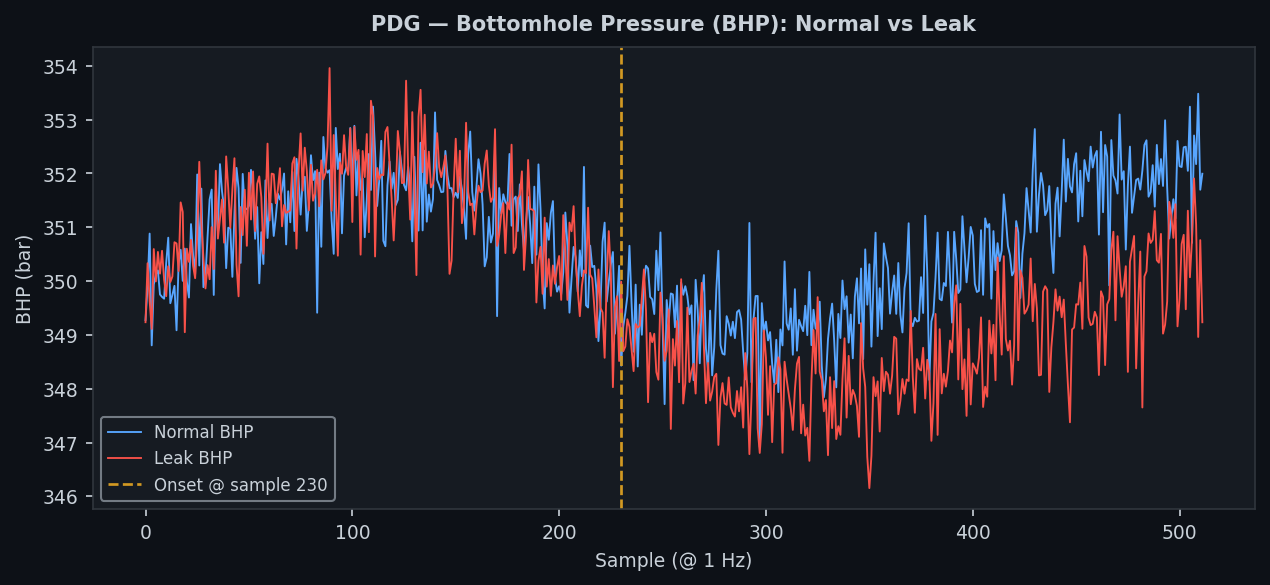


-- 02_das_signal_ch1.png --


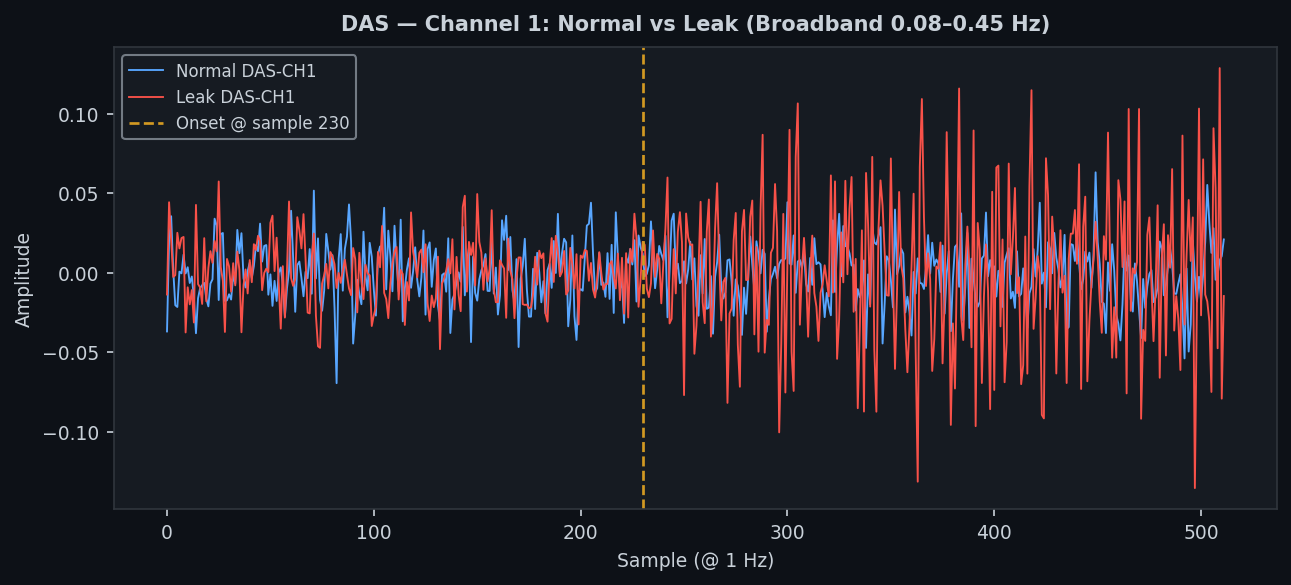


-- 03_das_spatial_profile.png --


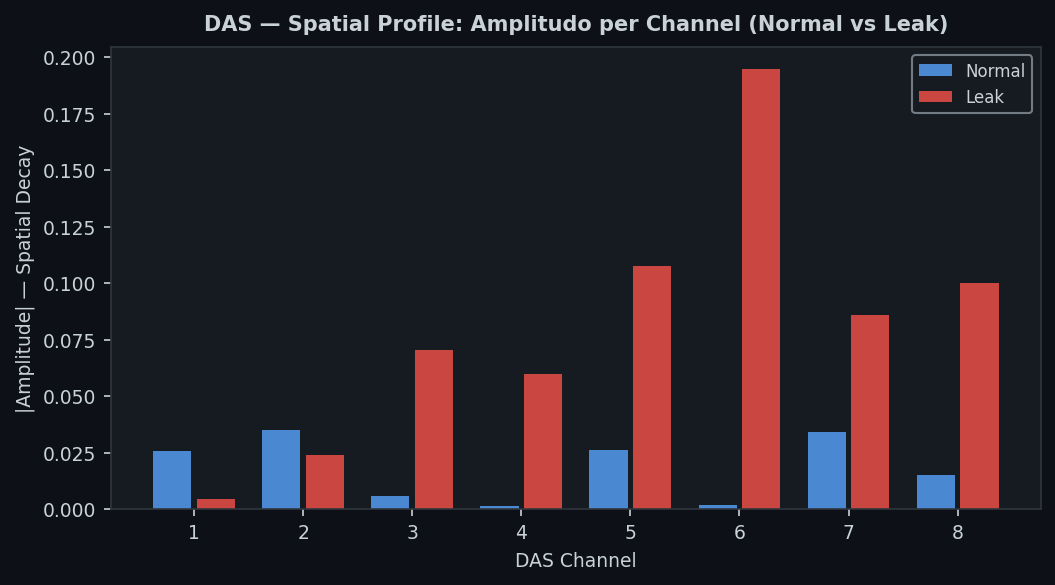


-- 04_ae_pdg_training.png --


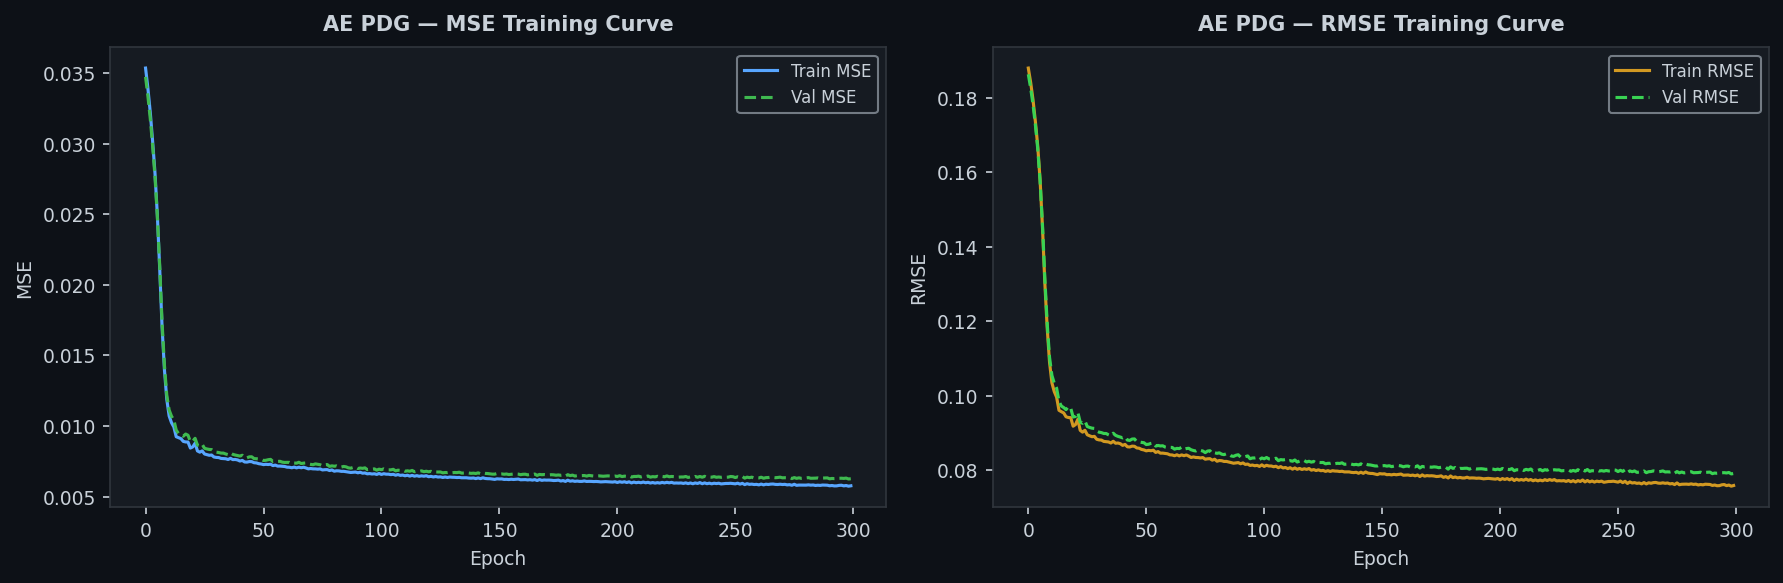


-- 05_ae_das_training.png --


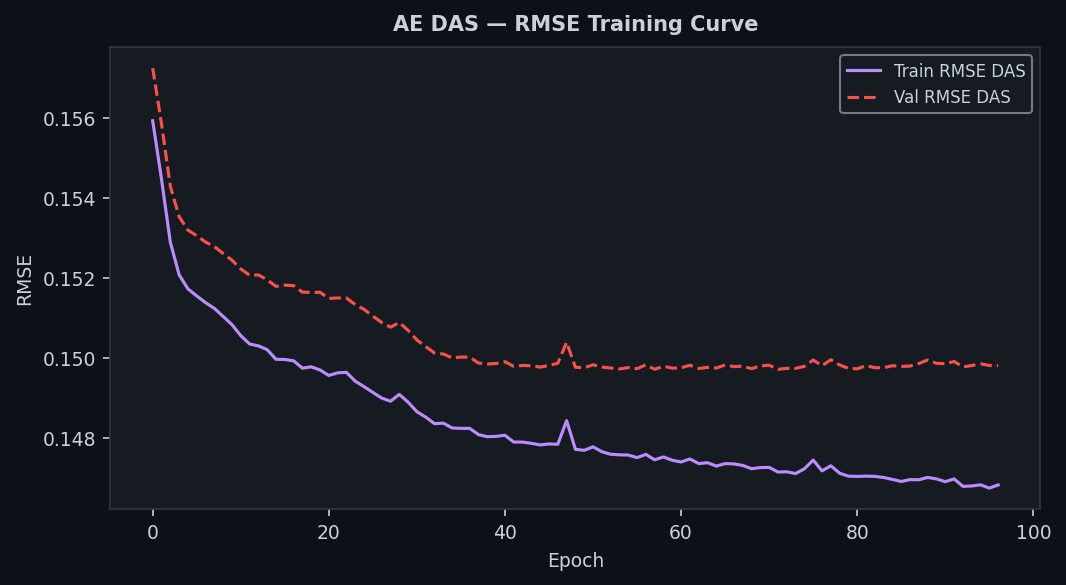


-- 06_rmse_pdg_distribution.png --


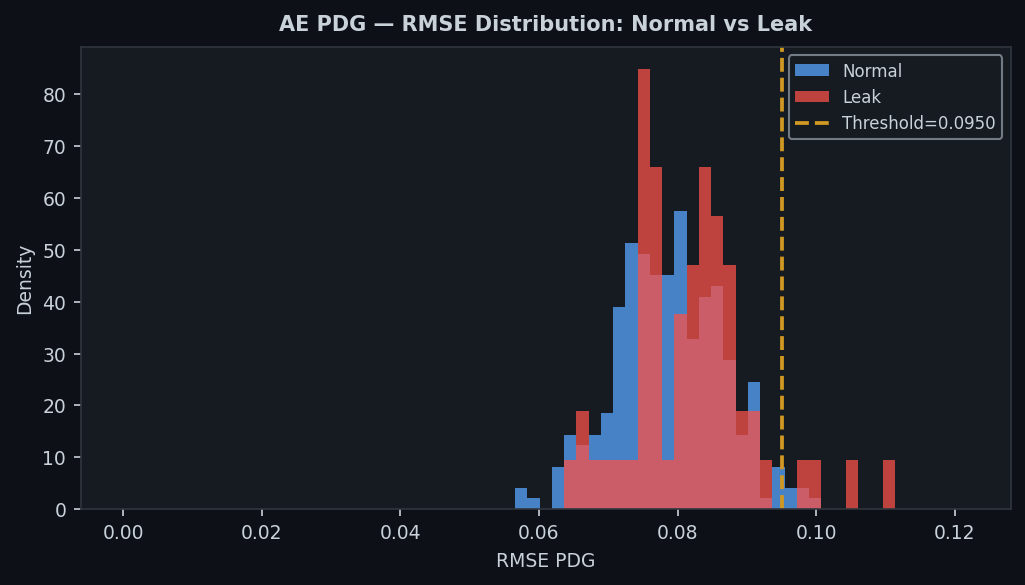


-- 07_rmse_das_distribution.png --


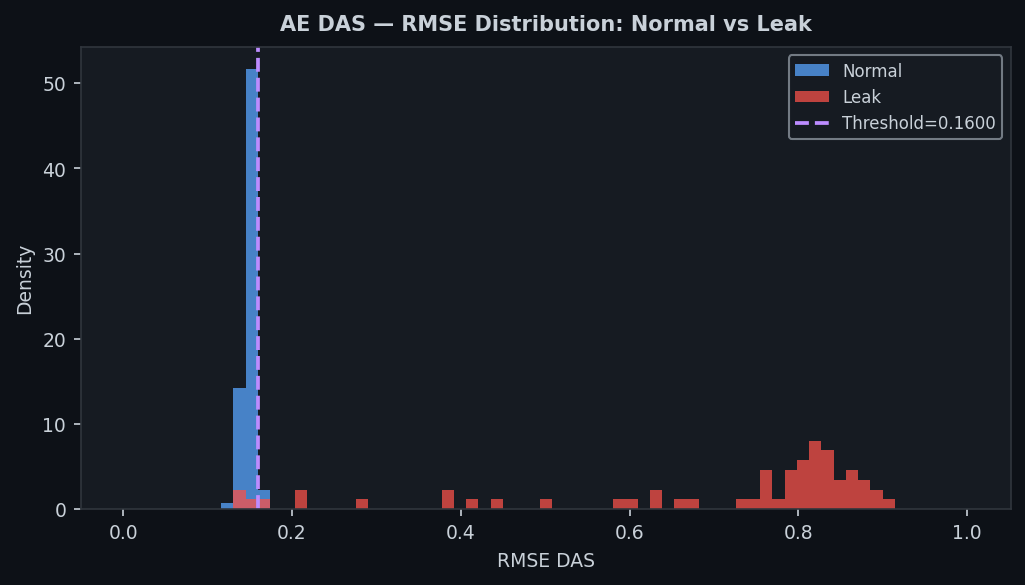


-- 08_isolation_forest_score.png --


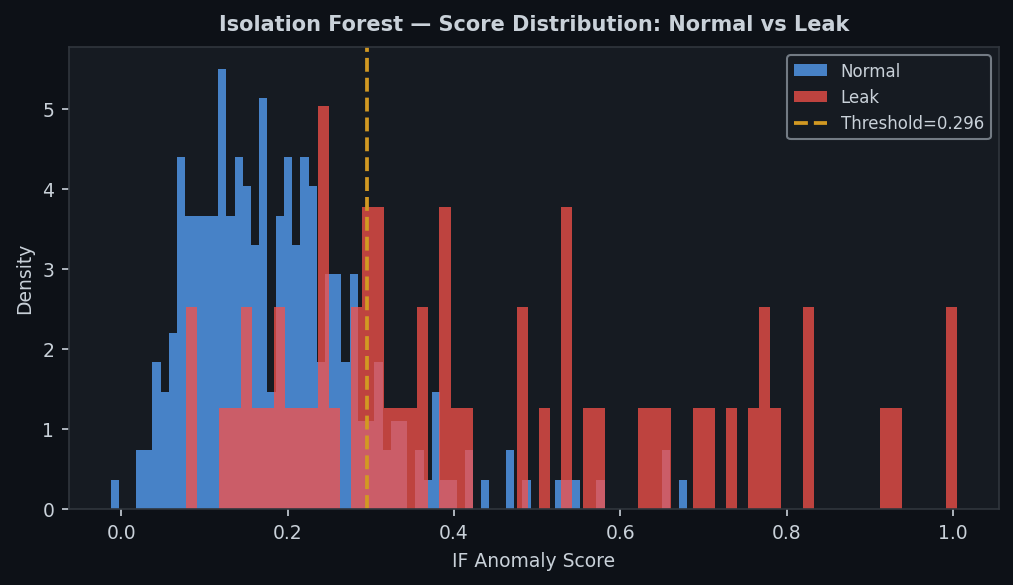


-- 09_combined_score_distribution.png --


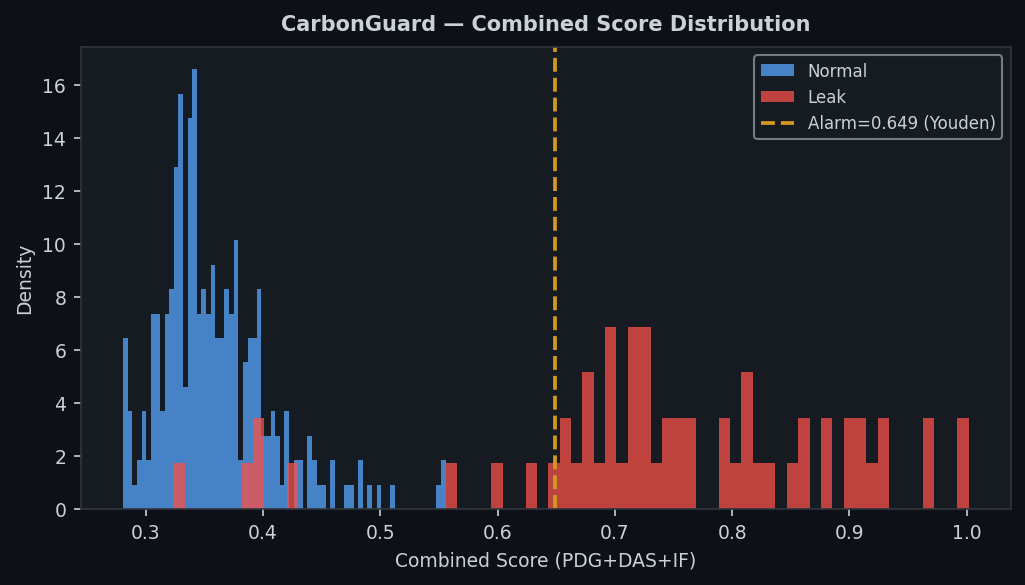


-- 10_roc_curve.png --


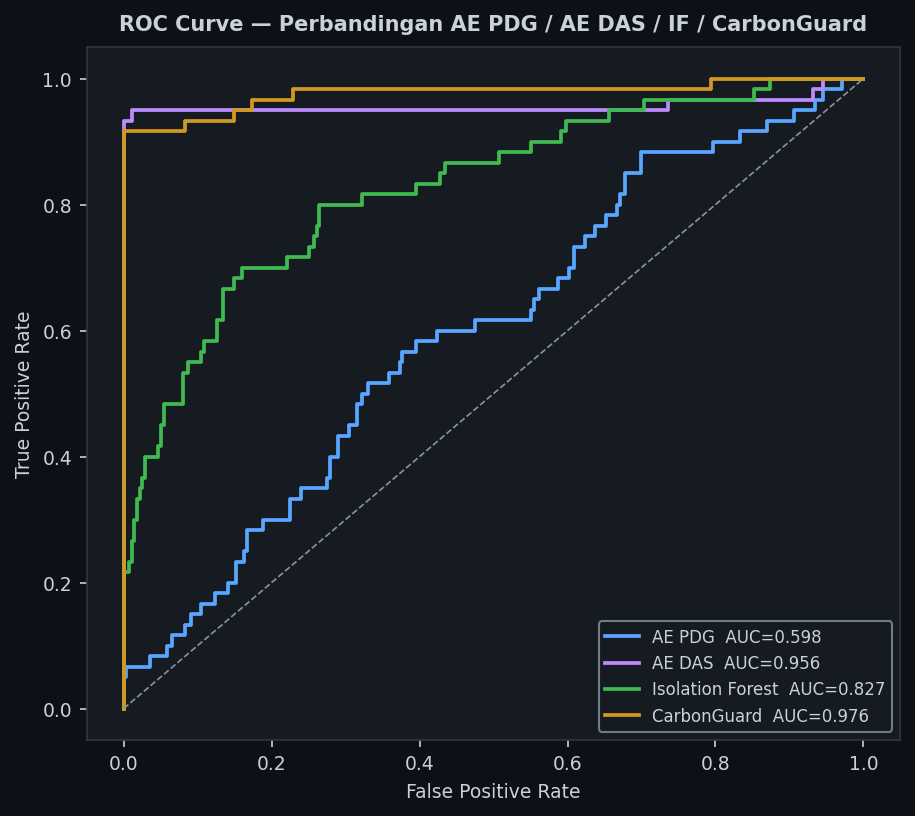


-- 11_confusion_matrix.png --


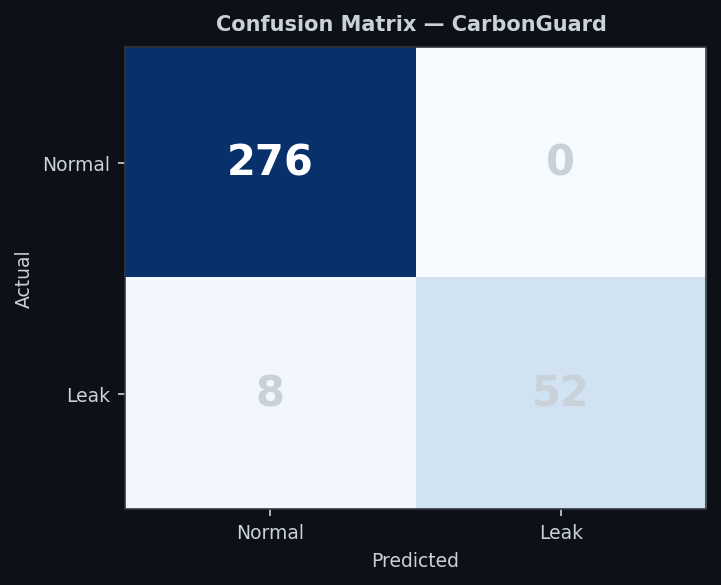


-- 12_ttd_distribution.png --


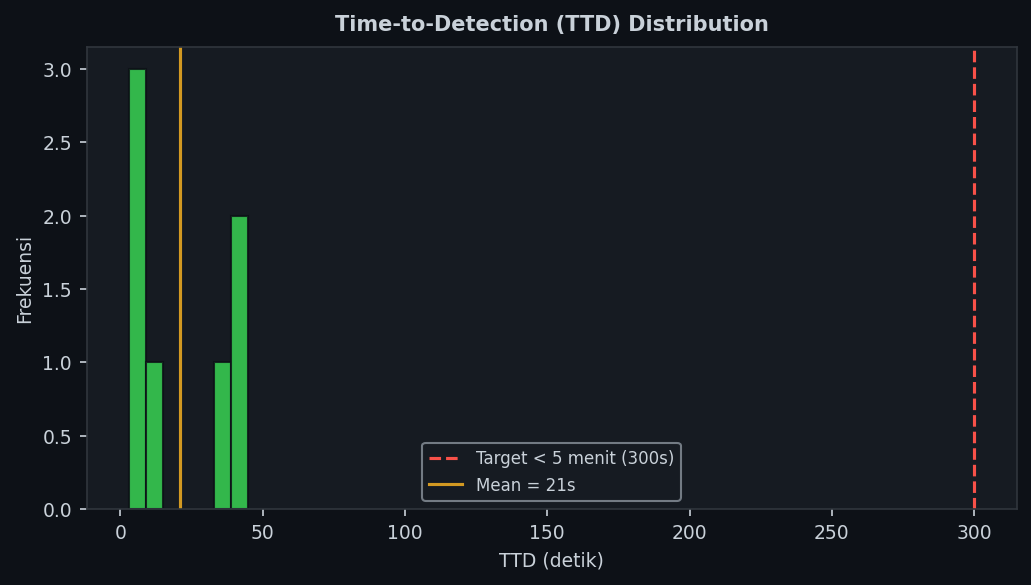


-- 13_scatter_rmse_pdg_vs_das.png --


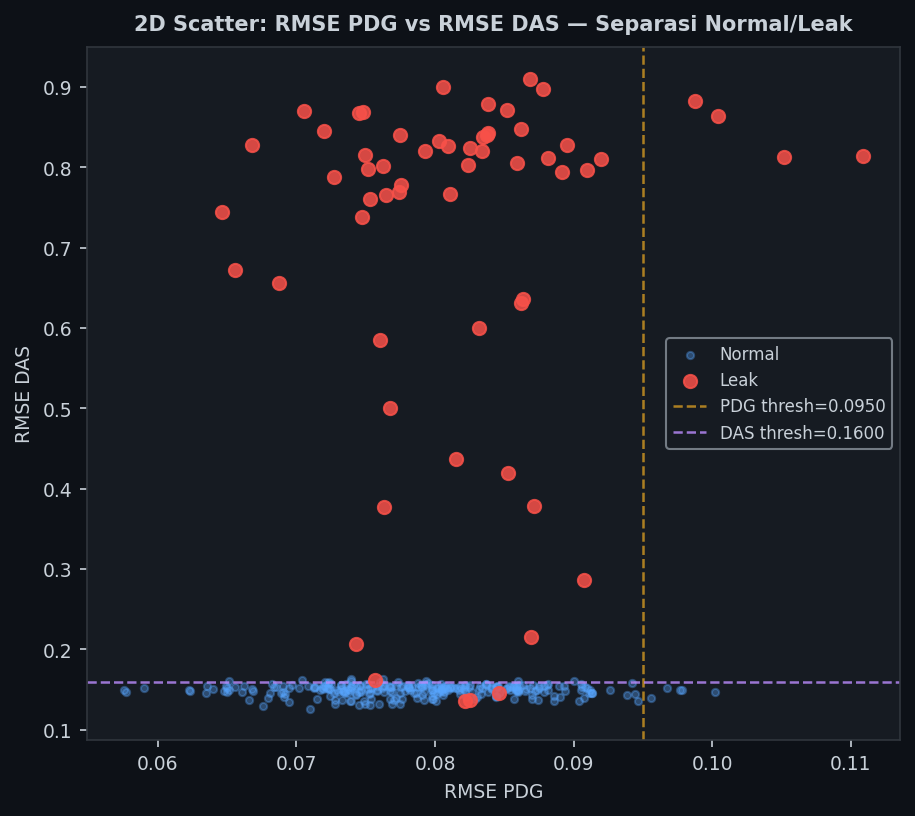


-- 14_score_timeline.png --


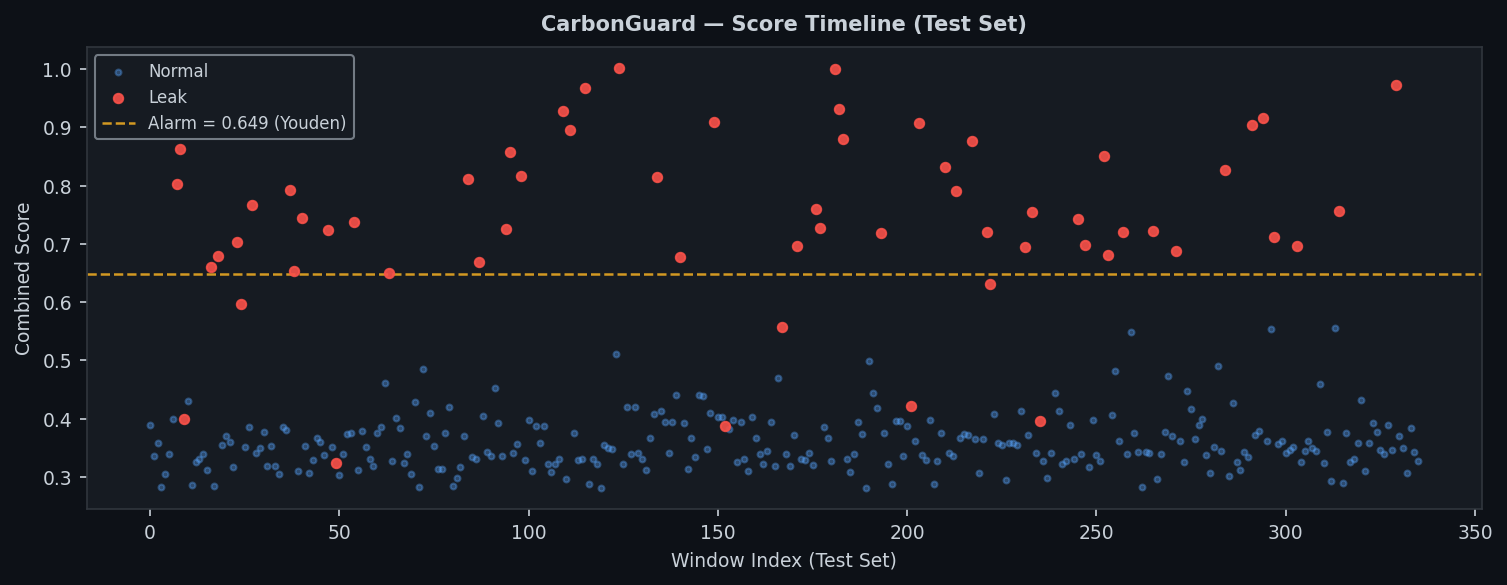


-- 15_metric_comparison.png --


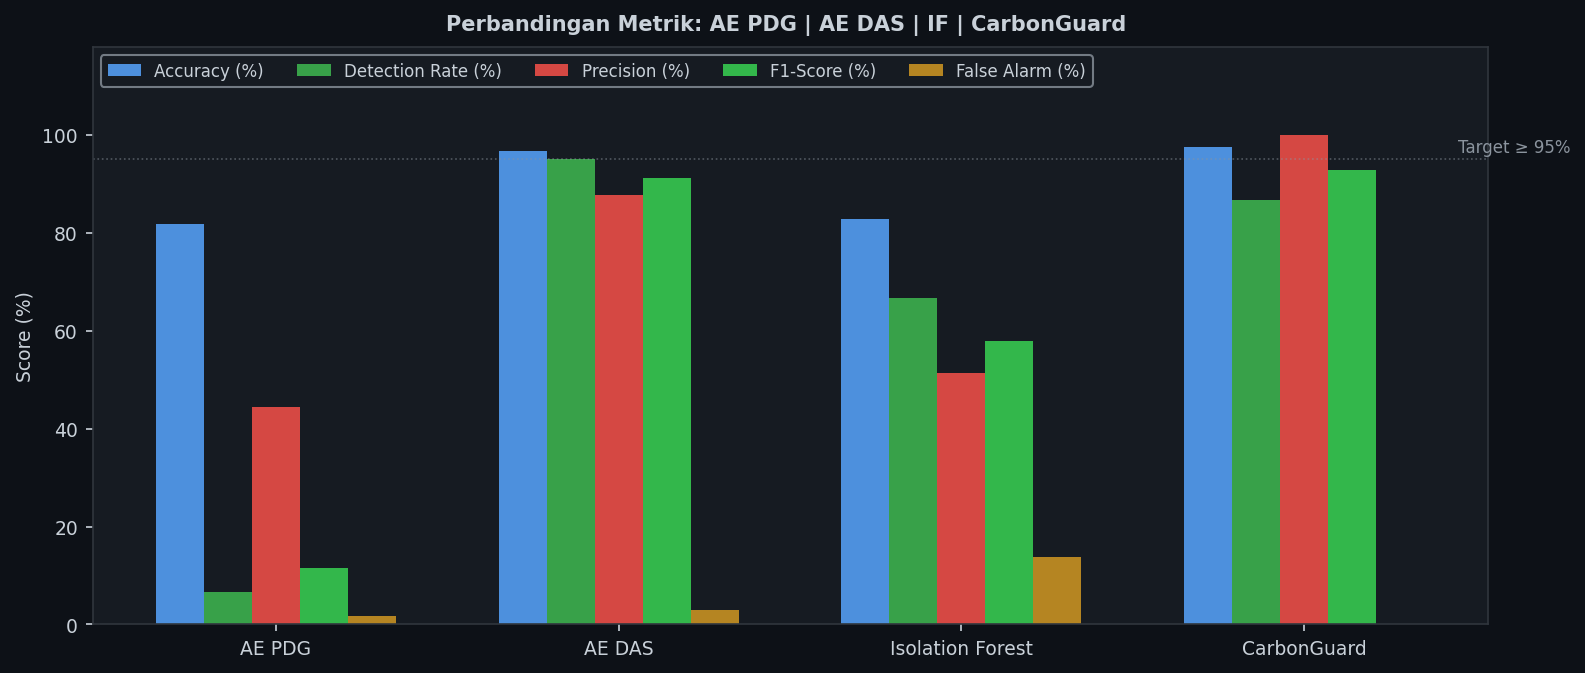

In [62]:
import os
from IPython.display import Image, display

output_dir = 'outputs'
# Mengambil semua file PNG yang diawali dengan angka (01-15)
image_files = sorted([f for f in os.listdir(output_dir) if f.endswith('.png')])

if not image_files:
    print(f"Tidak ditemukan file gambar di folder {output_dir}. Pastikan Anda sudah menjalankan sel utama.")
else:
    for img_file in image_files:
        print(f"\n-- {img_file} --")
        display(Image(filename=os.path.join(output_dir, img_file)))
